Implement an MLP to learn the XOR Boolean function
The XOR function takes two binary inputs (0 or 1) and produces a binary output (0 or 1) based on the
following rule:
Input 1 Input 2 XOR Output
0              0.               0
0              1.               1
1              0                1
1                1               0
Steps:
#### 1. Create the Dataset
##### Define input (X) and output (y) arrays for all 4 XOR combinations.
#### 2. Build an MLP
##### i. Input layer: size 2 (for the two inputs).
##### Hidden layer: at least 2 neurons with ReLU or Tanh activation.
##### Output layer: 1 neuron with sigmoid activation for binary classification.
#### 3. Compile the Model / Define Loss and Optimizer
##### Use Binary Cross-Entropy loss.
##### Use an optimizer of your choice (e.g., Adam or SGD).
#### 4. Train the Model
##### Train the model on the XOR dataset.
##### Experiment with epochs, learning rate, and number of neurons to improve
performance.
#### 5. Evaluate the Model
##### Predict outputs for all 4 input combinations.
##### Check if the network correctly learns the XOR function.
#### 6. Implement Using Three Libraries
##### Repeat the above steps using:
#### 1. Keras (TensorFlow high-level API)
#### 2. TensorFlow low-level API
#### Additional Exercises (Optional):
##### ●Plot the decision boundary for each implementation.
##### ●Compare training curves and final accuracy between libraries.
##### ●Discuss how changes in learning rate, activation function, hidden layers, or epochs affect
learning.


In [27]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt


# Display versions
print("TensorFlow version:", tf.__version__)
print("Keras backend:", keras.backend.backend())



# XOR DATASET


X_xor = tf.constant([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
], dtype=tf.float32)


y_xor = tf.constant([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
], dtype=tf.float32)


print("\n========== XOR DATASET ==========")

for i in range(len(X_xor)):
    print(
        X_xor[i].numpy(),
        "->",
        int(y_xor[i][0].numpy())
    )

TensorFlow version: 2.20.0
Keras backend: tensorflow

========== XOR DATASET ==========
[0. 0.] -> 0
[0. 1.] -> 1
[1. 0.] -> 1
[1. 1.] -> 0


The TensorFlow and Keras libraries were successfully imported, and the XOR dataset containing all four possible binary input combinations was created. This dataset is used to train and evaluate the Multi-Layer Perceptron (MLP).

In [28]:

# MANUAL MLP CLASS


class ManualMLP:

    def __init__(
        self,
        input_size=2,
        hidden_size=4,
        learning_rate=0.1
    ):

        self.learning_rate = learning_rate

        # Input Layer -> Hidden Layer
        self.W1 = tf.Variable(
            tf.random.normal(
                [input_size, hidden_size],
                stddev=0.5
            )
        )

        self.b1 = tf.Variable(
            tf.zeros([hidden_size])
        )

        # Hidden Layer -> Output Layer
        self.W2 = tf.Variable(
            tf.random.normal(
                [hidden_size, 1],
                stddev=0.5
            )
        )

        self.b2 = tf.Variable(
            tf.zeros([1])
        )



    # TANH ACTIVATION


    def tanh(self, value):
        return tf.math.tanh(value)



    # SIGMOID ACTIVATION


    def sigmoid(self, value):
        return tf.math.sigmoid(value)



    # FORWARD PROPAGATION


    def forward(self, inputs):

        # Input -> Hidden Layer
        hidden_input = (
            tf.matmul(inputs, self.W1)
            + self.b1
        )

        hidden_output = self.tanh(
            hidden_input
        )


        # Hidden -> Output Layer
        output_input = (
            tf.matmul(hidden_output, self.W2)
            + self.b2
        )

        output = self.sigmoid(
            output_input
        )

        return hidden_output, output



    # BINARY CROSS-ENTROPY LOSS


    def loss_function(self, target, prediction):

        epsilon = 1e-7

        prediction = tf.clip_by_value(
            prediction,
            epsilon,
            1.0 - epsilon
        )

        loss = -tf.reduce_mean(
            target * tf.math.log(prediction)
            +
            (1 - target)
            * tf.math.log(1 - prediction)
        )

        return loss



    # MANUAL TRAINING WITH BACKPROPAGATION


    def train(self, X, y, epochs):

        loss_history = []

        for epoch in range(epochs):


            # FORWARD PROPAGATION


            hidden_output, prediction = self.forward(X)


            # Calculate loss
            loss = self.loss_function(
                y,
                prediction
            )

            loss_history.append(
                float(loss.numpy())
            )



            # BACKPROPAGATION


            m = tf.cast(
                tf.shape(X)[0],
                tf.float32
            )



            # OUTPUT LAYER GRADIENTS


            # For Sigmoid + Binary Cross-Entropy
            output_error = prediction - y


            # Gradient for W2
            dW2 = tf.matmul(
                hidden_output,
                output_error,
                transpose_a=True
            ) / m


            # Gradient for b2
            db2 = tf.reduce_sum(
                output_error,
                axis=0
            ) / m



            # HIDDEN LAYER GRADIENTS


            hidden_error = tf.matmul(
                output_error,
                self.W2,
                transpose_b=True
            )


            # Derivative of Tanh
            tanh_derivative = (
                1 - tf.square(hidden_output)
            )


            hidden_delta = (
                hidden_error
                * tanh_derivative
            )


            # Gradient for W1
            dW1 = tf.matmul(
                X,
                hidden_delta,
                transpose_a=True
            ) / m


            # Gradient for b1
            db1 = tf.reduce_sum(
                hidden_delta,
                axis=0
            ) / m



            # MANUAL WEIGHT AND BIAS UPDATES


            self.W1.assign_sub(
                self.learning_rate * dW1
            )

            self.b1.assign_sub(
                self.learning_rate * db1
            )

            self.W2.assign_sub(
                self.learning_rate * dW2
            )

            self.b2.assign_sub(
                self.learning_rate * db2
            )


            # Display progress
            if (epoch + 1) % 1000 == 0:

                print(
                    f"Epoch {epoch + 1}/{epochs} | "
                    f"Loss: {loss.numpy():.6f}"
                )


        return loss_history

A Multi-Layer Perceptron was manually implemented with an input layer, a hidden layer containing four neurons, and an output layer containing one neuron. Tanh activation was used in the hidden layer and sigmoid activation was used in the output layer. Forward propagation, Binary Cross-Entropy loss, backpropagation, and manual weight updates were implemented.

In [29]:

# TRAIN MANUAL MLP

print("\n========== MANUAL MLP ==========")

manual_model = ManualMLP(
    input_size=2,
    hidden_size=4,
    learning_rate=0.1
)


manual_loss_history = manual_model.train(
    X_xor,
    y_xor,
    epochs=10000
)


========== MANUAL MLP ==========
Epoch 1000/10000 | Loss: 0.057662
Epoch 2000/10000 | Loss: 0.017458
Epoch 3000/10000 | Loss: 0.010099
Epoch 4000/10000 | Loss: 0.007079
Epoch 5000/10000 | Loss: 0.005442
Epoch 6000/10000 | Loss: 0.004417
Epoch 7000/10000 | Loss: 0.003716
Epoch 8000/10000 | Loss: 0.003206
Epoch 9000/10000 | Loss: 0.002819
Epoch 10000/10000 | Loss: 0.002515


The manually implemented MLP was trained on the XOR dataset for 10,000 epochs. During training, the loss decreased as the model updated its weights and biases, enabling it to learn the non-linear XOR relationship.

In [30]:

# MANUAL MLP RESULTS


_, manual_predictions = manual_model.forward(
    X_xor
)

manual_classes = tf.cast(
    manual_predictions >= 0.5,
    tf.int32
)


manual_accuracy = tf.reduce_mean(
    tf.cast(
        tf.equal(
            manual_classes,
            tf.cast(y_xor, tf.int32)
        ),
        tf.float32
    )
) * 100


print("\nResults:")

for i in range(len(X_xor)):

    print(
        X_xor[i].numpy(),
        "| Expected:",
        int(y_xor[i][0].numpy()),
        "| Probability:",
        f"{manual_predictions[i][0].numpy():.4f}",
        "| Predicted:",
        int(manual_classes[i][0].numpy())
    )


print(
    "\nManual MLP Accuracy:",
    manual_accuracy.numpy(),
    "%"
)


Results:
[0. 0.] | Expected: 0 | Probability: 0.0003 | Predicted: 0
[0. 1.] | Expected: 1 | Probability: 0.9972 | Predicted: 1
[1. 0.] | Expected: 1 | Probability: 0.9972 | Predicted: 1
[1. 1.] | Expected: 0 | Probability: 0.0041 | Predicted: 0

Manual MLP Accuracy: 100.0 %


The trained manual MLP was evaluated using all four XOR input combinations. The predicted outputs were compared with the expected outputs, and the accuracy was calculated. A correctly trained model should classify all four combinations correctly.

In [31]:

# KERAS MLP

print("\n========== KERAS MLP ==========")


keras_model = keras.Sequential([

    # Input layer
    keras.layers.Input(
        shape=(2,)
    ),

    # Hidden layer
    keras.layers.Dense(
        4,
        activation="tanh"
    ),

    # Output layer
    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])


keras_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.1
    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


keras_model.summary()


========== KERAS MLP ==========


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

An MLP was created using the Keras high-level API with two input features, four hidden neurons using the Tanh activation function, and one output neuron using the sigmoid activation function. The model was compiled using the Adam optimizer and Binary Cross-Entropy loss.

In [32]:

# TRAIN KERAS MODEL


keras_history = keras_model.fit(
    X_xor,
    y_xor,
    epochs=1000,
    verbose=0
)

print("Keras training completed.")

Keras training completed.


The Keras MLP was trained on the XOR dataset for 1,000 epochs. During training, Keras automatically performed forward propagation, loss calculation, backpropagation, and weight optimization.

In [33]:

# KERAS RESULTS


keras_loss, keras_accuracy = keras_model.evaluate(
    X_xor,
    y_xor,
    verbose=0
)


keras_predictions = keras_model.predict(
    X_xor,
    verbose=0
)


keras_classes = tf.cast(
    keras_predictions >= 0.5,
    tf.int32
)


print("\nResults:")

for i in range(len(X_xor)):

    print(
        X_xor[i].numpy(),
        "| Expected:",
        int(y_xor[i][0].numpy()),
        "| Probability:",
        f"{keras_predictions[i][0]:.4f}",
        "| Predicted:",
        int(keras_classes[i][0].numpy())
    )


print(
    "\nKeras Accuracy:",
    keras_accuracy * 100,
    "%"
)


Results:
[0. 0.] | Expected: 0 | Probability: 0.0000 | Predicted: 0
[0. 1.] | Expected: 1 | Probability: 0.9998 | Predicted: 1
[1. 0.] | Expected: 1 | Probability: 0.9998 | Predicted: 1
[1. 1.] | Expected: 0 | Probability: 0.0002 | Predicted: 0

Keras Accuracy: 100.0 %


The Keras model was evaluated on all four XOR input combinations. The predicted probabilities were converted into binary classes using a threshold of 0.5 and compared with the expected outputs to calculate the final accuracy.

In [34]:

# TENSORFLOW LOW-LEVEL MLP


print("\n========== TENSORFLOW LOW-LEVEL MLP ==========")


# Network configuration
input_size = 2
hidden_size = 4


# Input -> Hidden Layer
W1_tf = tf.Variable(
    tf.random.normal(
        [input_size, hidden_size],
        stddev=0.5
    )
)

b1_tf = tf.Variable(
    tf.zeros([hidden_size])
)


# Hidden -> Output Layer
W2_tf = tf.Variable(
    tf.random.normal(
        [hidden_size, 1],
        stddev=0.5
    )
)

b2_tf = tf.Variable(
    tf.zeros([1])
)


========== TENSORFLOW LOW-LEVEL MLP ==========


The weights and biases for a two-layer MLP were manually initialized using TensorFlow variables. The network consists of two input neurons, four hidden neurons, and one output neuron.

In [35]:

# FORWARD PROPAGATION


def tensorflow_forward(inputs):

    # Input -> Hidden Layer
    hidden_input = (
        tf.matmul(inputs, W1_tf)
        + b1_tf
    )

    hidden_output = tf.math.tanh(
        hidden_input
    )


    # Hidden -> Output Layer
    output_input = (
        tf.matmul(hidden_output, W2_tf)
        + b2_tf
    )

    output = tf.math.sigmoid(
        output_input
    )

    return output

The forward propagation process was defined manually using matrix multiplication. The hidden layer uses the Tanh activation function to learn non-linear patterns, while the output layer uses the sigmoid function to produce a probability between 0 and 1.

In [36]:

# LOSS AND OPTIMIZER


loss_function = tf.keras.losses.BinaryCrossentropy()


optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.1
)

Binary Cross-Entropy was selected as the loss function because XOR is a binary classification problem. The Adam optimizer was used with a learning rate of 0.1 to update the model parameters during training.

In [37]:

# TRAIN TENSORFLOW LOW-LEVEL MODEL


tf_loss_history = []

epochs_tf = 1000


for epoch in range(epochs_tf):

    # Record operations
    with tf.GradientTape() as tape:

        # Forward propagation
        predictions = tensorflow_forward(
            X_xor
        )

        # Calculate Binary Cross-Entropy loss
        loss = loss_function(
            y_xor,
            predictions
        )


    # Variables to optimize
    variables = [
        W1_tf,
        b1_tf,
        W2_tf,
        b2_tf
    ]


    # Automatically calculate gradients
    gradients = tape.gradient(
        loss,
        variables
    )


    # Update variables
    optimizer.apply_gradients(
        zip(
            gradients,
            variables
        )
    )


    # Store loss
    tf_loss_history.append(
        float(loss.numpy())
    )


    # Display progress
    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch {epoch + 1}/{epochs_tf} | "
            f"Loss: {loss.numpy():.6f}"
        )

Epoch 100/1000 | Loss: 0.004121
Epoch 200/1000 | Loss: 0.001703
Epoch 300/1000 | Loss: 0.000965
Epoch 400/1000 | Loss: 0.000633
Epoch 500/1000 | Loss: 0.000452
Epoch 600/1000 | Loss: 0.000342
Epoch 700/1000 | Loss: 0.000269
Epoch 800/1000 | Loss: 0.000217
Epoch 900/1000 | Loss: 0.000180
Epoch 1000/1000 | Loss: 0.000151


The TensorFlow low-level MLP was trained for 1,000 epochs. GradientTape automatically calculated the gradients of the loss with respect to the weights and biases, and the Adam optimizer updated the parameters to reduce the loss.

In [38]:

# TENSORFLOW LOW-LEVEL RESULTS


tf_predictions = tensorflow_forward(
    X_xor
)


tf_classes = tf.cast(
    tf_predictions >= 0.5,
    tf.int32
)


tf_accuracy = tf.reduce_mean(
    tf.cast(
        tf.equal(
            tf_classes,
            tf.cast(y_xor, tf.int32)
        ),
        tf.float32
    )
) * 100


print("\nResults:")

for i in range(len(X_xor)):

    print(
        X_xor[i].numpy(),
        "| Expected:",
        int(y_xor[i][0].numpy()),
        "| Probability:",
        f"{tf_predictions[i][0].numpy():.4f}",
        "| Predicted:",
        int(tf_classes[i][0].numpy())
    )


print(
    "\nTensorFlow Low-Level Accuracy:",
    tf_accuracy.numpy(),
    "%"
)


Results:
[0. 0.] | Expected: 0 | Probability: 0.0000 | Predicted: 0
[0. 1.] | Expected: 1 | Probability: 0.9999 | Predicted: 1
[1. 0.] | Expected: 1 | Probability: 0.9997 | Predicted: 1
[1. 1.] | Expected: 0 | Probability: 0.0002 | Predicted: 0

TensorFlow Low-Level Accuracy: 100.0 %


The trained TensorFlow model was tested using all XOR combinations. The output probabilities were converted into binary predictions and compared with the expected values to calculate the model accuracy.

In [39]:

# FINAL COMPARISON


print("\n" + "=" * 55)
print("FINAL XOR MLP COMPARISON")
print("=" * 55)

print(
    f"Manual MLP Accuracy: "
    f"{manual_accuracy.numpy():.2f}%"
)

print(
    f"Keras Accuracy: "
    f"{keras_accuracy * 100:.2f}%"
)

print(
    f"TensorFlow Low-Level Accuracy: "
    f"{tf_accuracy.numpy():.2f}%"
)

print("=" * 55)


FINAL XOR MLP COMPARISON
Manual MLP Accuracy: 100.00%
Keras Accuracy: 100.00%
TensorFlow Low-Level Accuracy: 100.00%


The final accuracies of the Manual MLP, Keras MLP, and TensorFlow low-level MLP were displayed together. This allows the performance of the three implementations to be compared.

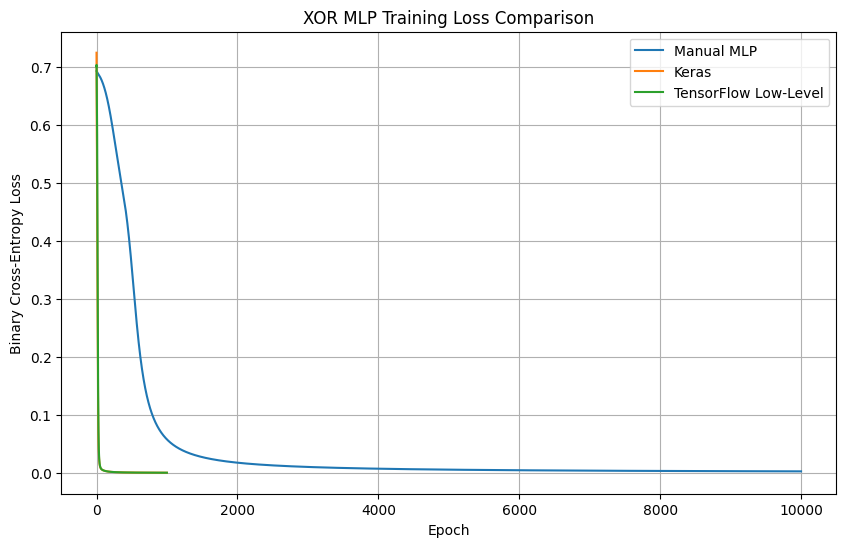

In [40]:

# TRAINING LOSS COMPARISON


plt.figure(figsize=(10, 6))

plt.plot(
    manual_loss_history,
    label="Manual MLP"
)

plt.plot(
    keras_history.history["loss"],
    label="Keras"
)

plt.plot(
    tf_loss_history,
    label="TensorFlow Low-Level"
)

plt.title("XOR MLP Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.legend()
plt.grid(True)

plt.show()

The graph compares the Binary Cross-Entropy loss during training for the three implementations. A decreasing loss indicates that the models are learning the XOR pattern. The curves may differ because the implementations use different training procedures and numbers of epochs.

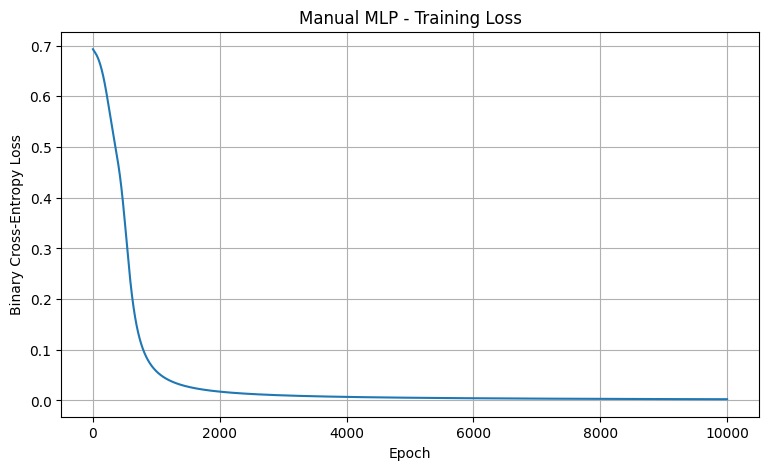

In [41]:

# MANUAL MLP LOSS CURVE


plt.figure(figsize=(9, 5))

plt.plot(manual_loss_history)

plt.title("Manual MLP - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.grid(True)
plt.show()

The graph shows how the loss of the manually implemented MLP changes over 10,000 training epochs. A gradual reduction in loss demonstrates that manual backpropagation and weight updates successfully trained the network.

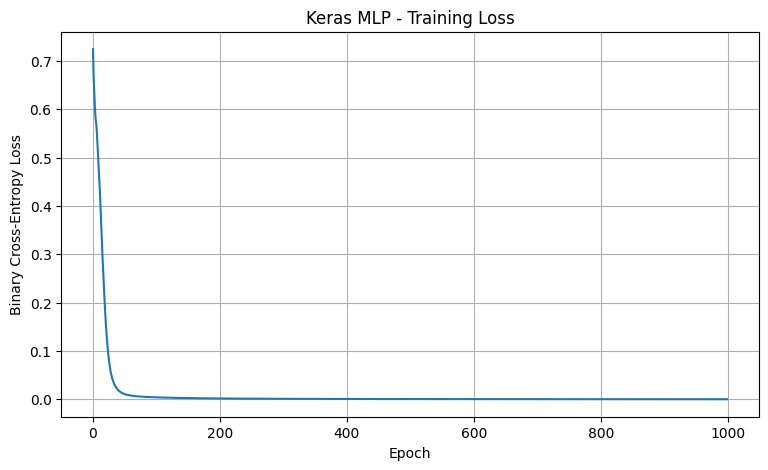

In [42]:

# KERAS LOSS CURVE


plt.figure(figsize=(9, 5))

plt.plot(keras_history.history["loss"])

plt.title("Keras MLP - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.grid(True)
plt.show()

The graph shows the training loss of the Keras MLP. The decreasing trend indicates that the model is learning the XOR relationship and improving its predictions during training.

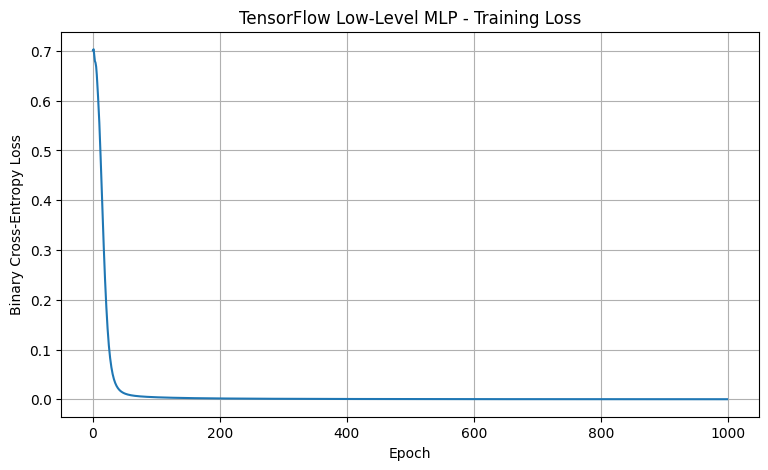

In [43]:

# TENSORFLOW LOW-LEVEL LOSS CURVE


plt.figure(figsize=(9, 5))

plt.plot(tf_loss_history)

plt.title("TensorFlow Low-Level MLP - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.grid(True)
plt.show()

The graph displays the loss during training of the TensorFlow low-level MLP. A decreasing loss indicates that GradientTape and the optimizer successfully adjusted the model parameters.

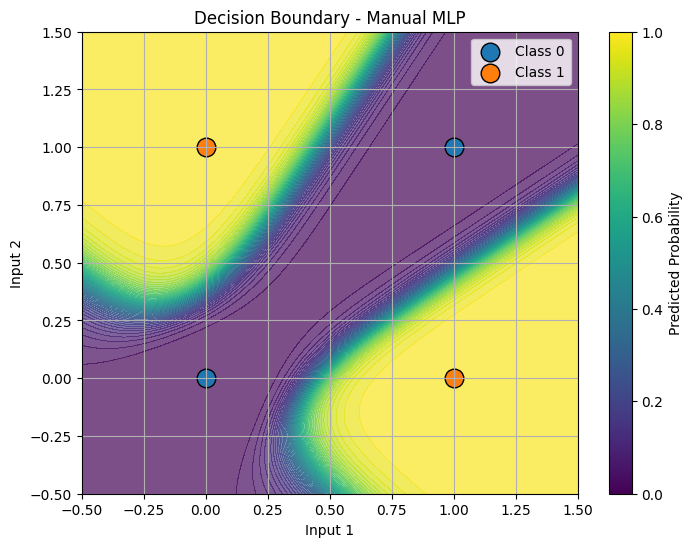

In [44]:

# DECISION BOUNDARY - MANUAL MLP
X_np = X_xor.numpy()
y_np = y_xor.numpy().flatten()
import numpy as np
# Create a grid of points
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Combine grid points
grid_points = np.c_[
    xx.ravel(),
    yy.ravel()
]

# Convert to TensorFlow tensor
grid_tensor = tf.constant(
    grid_points,
    dtype=tf.float32
)

# Predict using Manual MLP
_, grid_predictions = manual_model.forward(
    grid_tensor
)

# Reshape predictions
Z = grid_predictions.numpy().reshape(xx.shape)


# Plot colored decision regions
plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    levels=50,
    alpha=0.7
)

# Plot XOR points
plt.scatter(
    X_np[y_np == 0, 0],
    X_np[y_np == 0, 1],
    s=180,
    label="Class 0",
    edgecolors="black"
)

plt.scatter(
    X_np[y_np == 1, 0],
    X_np[y_np == 1, 1],
    s=180,
    label="Class 1",
    edgecolors="black"
)

plt.colorbar(label="Predicted Probability")

plt.title("Decision Boundary - Manual MLP")
plt.xlabel("Input 1")
plt.ylabel("Input 2")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.legend()
plt.grid(True)

plt.show()

The colored decision boundary visualizes how the manually implemented MLP classifies different input regions. The model learns a non-linear decision boundary that separates the XOR classes, demonstrating why the hidden layer is necessary.

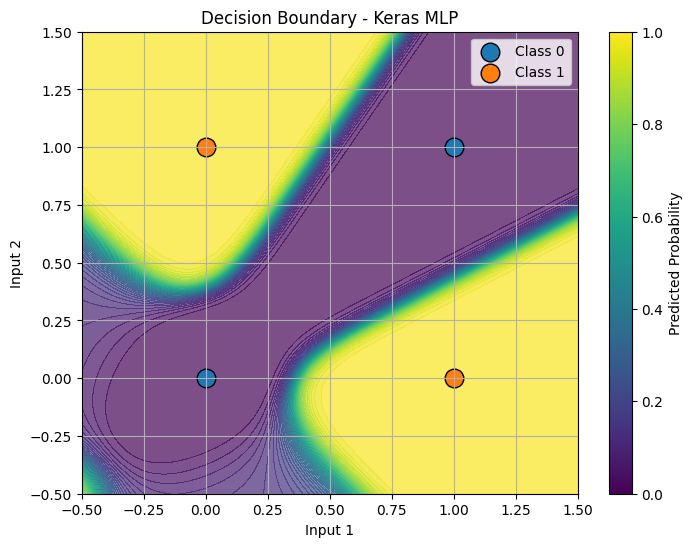

In [45]:

# DECISION BOUNDARY - KERAS MLP


# Predict grid points
grid_predictions_keras = keras_model.predict(
    grid_points,
    verbose=0
)

# Reshape predictions
Z_keras = grid_predictions_keras.reshape(
    xx.shape
)


plt.figure(figsize=(8, 6))

# Colored prediction regions
plt.contourf(
    xx,
    yy,
    Z_keras,
    levels=50,
    alpha=0.7
)

# Class 0 points
plt.scatter(
    X_np[y_np == 0, 0],
    X_np[y_np == 0, 1],
    s=180,
    label="Class 0",
    edgecolors="black"
)

# Class 1 points
plt.scatter(
    X_np[y_np == 1, 0],
    X_np[y_np == 1, 1],
    s=180,
    label="Class 1",
    edgecolors="black"
)

plt.colorbar(
    label="Predicted Probability"
)

plt.title("Decision Boundary - Keras MLP")
plt.xlabel("Input 1")
plt.ylabel("Input 2")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.legend()
plt.grid(True)

plt.show()

The colored regions represent the probabilities predicted by the Keras MLP for different input values. The graph demonstrates that the Keras model successfully learns a non-linear pattern capable of separating the XOR outputs.

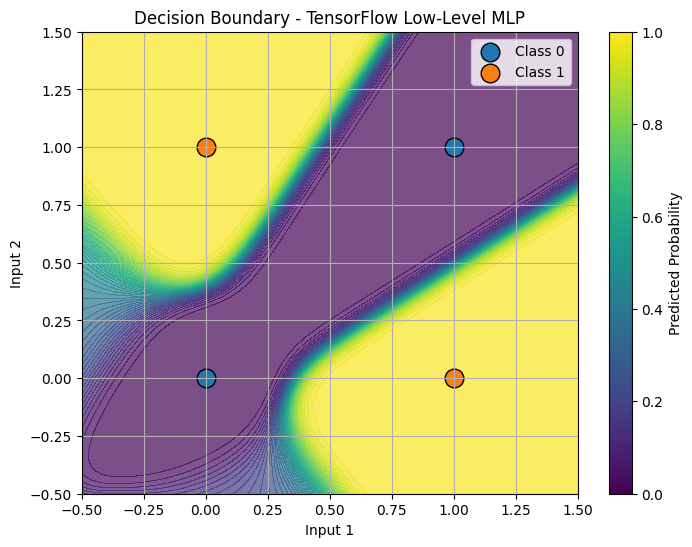

In [46]:

# DECISION BOUNDARY - TENSORFLOW LOW-LEVEL MLP


# Convert grid to TensorFlow
grid_tensor = tf.constant(
    grid_points,
    dtype=tf.float32
)

# Predict
grid_predictions_tf = tensorflow_forward(
    grid_tensor
)

# Reshape
Z_tf = grid_predictions_tf.numpy().reshape(
    xx.shape
)


plt.figure(figsize=(8, 6))

# Colored decision regions
plt.contourf(
    xx,
    yy,
    Z_tf,
    levels=50,
    alpha=0.7
)

# Plot class 0
plt.scatter(
    X_np[y_np == 0, 0],
    X_np[y_np == 0, 1],
    s=180,
    label="Class 0",
    edgecolors="black"
)

# Plot class 1
plt.scatter(
    X_np[y_np == 1, 0],
    X_np[y_np == 1, 1],
    s=180,
    label="Class 1",
    edgecolors="black"
)

plt.colorbar(
    label="Predicted Probability"
)

plt.title(
    "Decision Boundary - TensorFlow Low-Level MLP"
)

plt.xlabel("Input 1")
plt.ylabel("Input 2")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.legend()
plt.grid(True)

plt.show()

This graph visualizes the decision boundary learned by the TensorFlow low-level MLP. The colored regions show the predicted probability for each input location, confirming that the network has learned the non-linear XOR relationship.

In [ ]:

# HYPERPARAMETER EXPERIMENT 1
# EFFECT OF NUMBER OF HIDDEN NEURONS


neuron_counts = [2, 4, 8, 16]
neuron_accuracies = []
neuron_losses = []

for neurons in neuron_counts:

    model = keras.Sequential([
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(neurons, activation="tanh"),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.1),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_xor,
        y_xor,
        epochs=1000,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_xor,
        y_xor,
        verbose=0
    )

    neuron_losses.append(loss)
    neuron_accuracies.append(accuracy * 100)


print("========== HIDDEN NEURON EXPERIMENT ==========")

for neurons, loss, accuracy in zip(
    neuron_counts,
    neuron_losses,
    neuron_accuracies
):
    print(
        f"Neurons: {neurons} | "
        f"Loss: {loss:.6f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

========== HIDDEN NEURON EXPERIMENT ==========
Neurons: 2 | Loss: 0.000311 | Accuracy: 100.00%
Neurons: 4 | Loss: 0.000221 | Accuracy: 100.00%
Neurons: 8 | Loss: 0.000065 | Accuracy: 100.00%
Neurons: 16 | Loss: 0.000025 | Accuracy: 100.00%


### Hyperparameter Analysis: Number of Hidden Neurons

Different hidden layer configurations containing 2, 4, 8, and 16 neurons were tested while keeping the other hyperparameters constant. This experiment evaluates how the number of neurons affects the ability of the MLP to learn the non-linear XOR function.

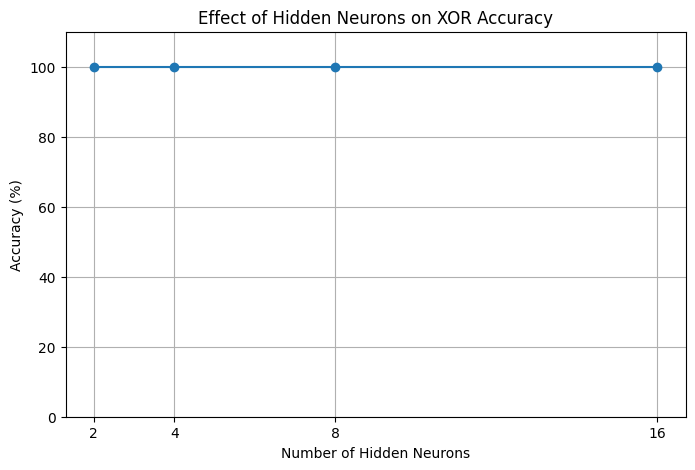

In [ ]:

# GRAPH: HIDDEN NEURONS VS ACCURACY


plt.figure(figsize=(8, 5))

plt.plot(
    neuron_counts,
    neuron_accuracies,
    marker="o"
)

plt.title("Effect of Hidden Neurons on XOR Accuracy")
plt.xlabel("Number of Hidden Neurons")
plt.ylabel("Accuracy (%)")

plt.xticks(neuron_counts)
plt.ylim(0, 110)
plt.grid(True)

plt.show()

========== LEARNING RATE EXPERIMENT ==========
Learning Rate: 0.001 | Loss: 0.261539 | Accuracy: 100.00%
Learning Rate: 0.01 | Loss: 0.001952 | Accuracy: 100.00%
Learning Rate: 0.05 | Loss: 0.346727 | Accuracy: 50.00%
Learning Rate: 0.1 | Loss: 0.000161 | Accuracy: 100.00%


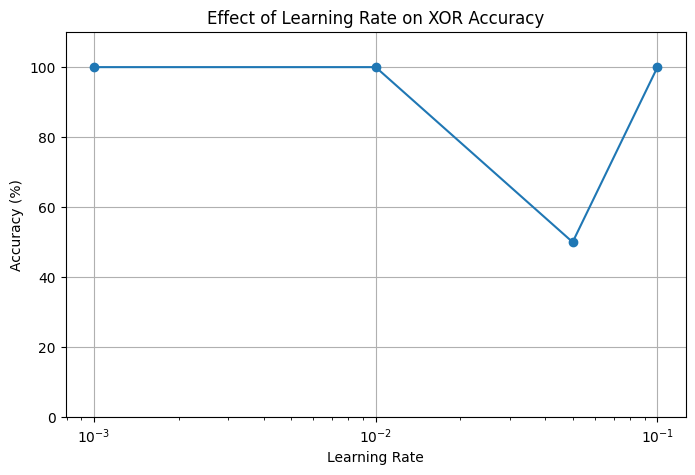

In [ ]:

# HYPERPARAMETER EXPERIMENT 2
# EFFECT OF LEARNING RATE

learning_rates = [0.001, 0.01, 0.05, 0.1]
learning_rate_accuracies = []
learning_rate_losses = []

for lr in learning_rates:

    model = keras.Sequential([
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(4, activation="tanh"),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_xor,
        y_xor,
        epochs=1000,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_xor,
        y_xor,
        verbose=0
    )

    learning_rate_losses.append(loss)
    learning_rate_accuracies.append(accuracy * 100)


print("========== LEARNING RATE EXPERIMENT ==========")

for lr, loss, accuracy in zip(
    learning_rates,
    learning_rate_losses,
    learning_rate_accuracies
):
    print(
        f"Learning Rate: {lr} | "
        f"Loss: {loss:.6f} | "
        f"Accuracy: {accuracy:.2f}%"
    )


# ============================================================
# GRAPH: LEARNING RATE VS ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    learning_rates,
    learning_rate_accuracies,
    marker="o"
)

plt.title("Effect of Learning Rate on XOR Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy (%)")

plt.xscale("log")
plt.ylim(0, 110)
plt.grid(True)

plt.show()

### Hyperparameter Analysis: Learning Rate

Different learning rates were tested while keeping the network architecture and number of training epochs constant. The learning rate controls the size of the weight updates during training and therefore affects the speed and stability of learning.

In [ ]:

# HYPERPARAMETER EXPERIMENT 3
# EFFECT OF ACTIVATION FUNCTION


activations = ["tanh", "relu", "sigmoid"]
activation_accuracies = []
activation_losses = []

for activation in activations:

    model = keras.Sequential([
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(4, activation=activation),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.1),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_xor,
        y_xor,
        epochs=1000,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_xor,
        y_xor,
        verbose=0
    )

    activation_losses.append(loss)
    activation_accuracies.append(accuracy * 100)


print("========== ACTIVATION FUNCTION EXPERIMENT ==========")

for activation, loss, accuracy in zip(
    activations,
    activation_losses,
    activation_accuracies
):
    print(
        f"Activation: {activation} | "
        f"Loss: {loss:.6f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

========== ACTIVATION FUNCTION EXPERIMENT ==========
Activation: tanh | Loss: 0.000137 | Accuracy: 100.00%
Activation: relu | Loss: 0.000105 | Accuracy: 100.00%
Activation: sigmoid | Loss: 0.000627 | Accuracy: 100.00%


### Hyperparameter Analysis: Activation Function

Different activation functions were tested in the hidden layer while keeping the number of neurons, learning rate, and epochs constant. This experiment examines how the choice of non-linear activation function affects the learning performance of the MLP.

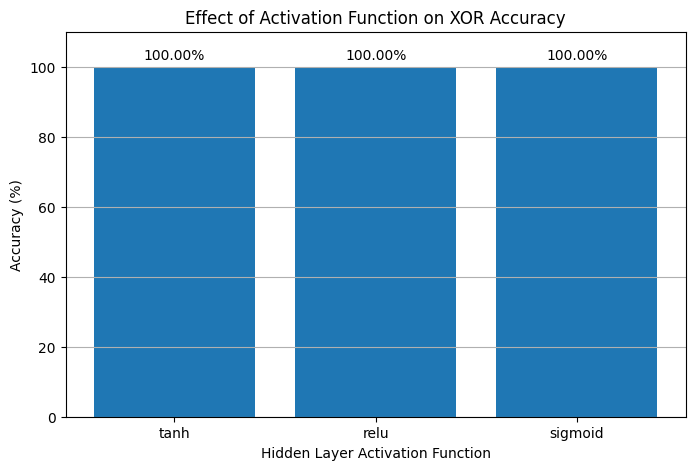

In [ ]:

# GRAPH: ACTIVATION FUNCTION VS ACCURACY


plt.figure(figsize=(8, 5))

plt.bar(
    activations,
    activation_accuracies
)

plt.title("Effect of Activation Function on XOR Accuracy")
plt.xlabel("Hidden Layer Activation Function")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 110)
plt.grid(axis="y")

for i, accuracy in enumerate(activation_accuracies):
    plt.text(
        i,
        accuracy + 2,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

In [ ]:

# HYPERPARAMETER EXPERIMENT 4
# EFFECT OF NUMBER OF EPOCHS

epoch_values = [100, 500, 1000, 2000]
epoch_accuracies = []
epoch_losses = []

for epochs in epoch_values:

    model = keras.Sequential([
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(4, activation="tanh"),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.1),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_xor,
        y_xor,
        epochs=epochs,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_xor,
        y_xor,
        verbose=0
    )

    epoch_losses.append(loss)
    epoch_accuracies.append(accuracy * 100)


print("========== EPOCH EXPERIMENT ==========")

for epochs, loss, accuracy in zip(
    epoch_values,
    epoch_losses,
    epoch_accuracies
):
    print(
        f"Epochs: {epochs} | "
        f"Loss: {loss:.6f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

========== EPOCH EXPERIMENT ==========
Epochs: 100 | Loss: 0.003358 | Accuracy: 100.00%
Epochs: 500 | Loss: 0.000246 | Accuracy: 100.00%
Epochs: 1000 | Loss: 0.000066 | Accuracy: 100.00%
Epochs: 2000 | Loss: 0.000056 | Accuracy: 100.00%


### Hyperparameter Analysis: Number of Epochs

The model was trained using different numbers of epochs while keeping the other hyperparameters constant. This experiment evaluates how additional training iterations affect the model's ability to learn the XOR relationship and reduce the prediction error.

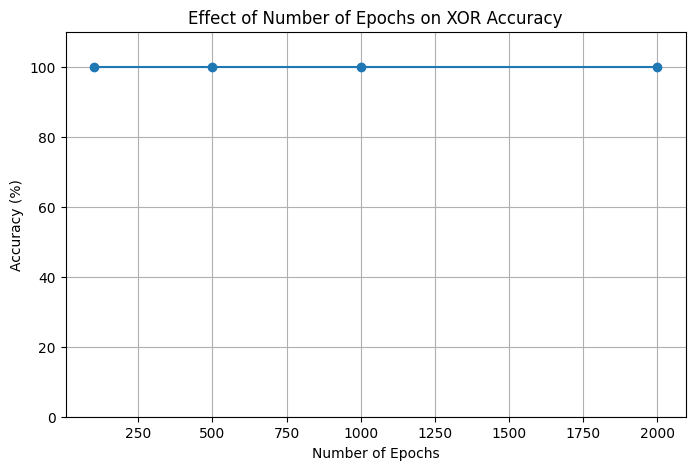

In [ ]:

# GRAPH: EPOCHS VS ACCURACY

plt.figure(figsize=(8, 5))

plt.plot(
    epoch_values,
    epoch_accuracies,
    marker="o"
)

plt.title("Effect of Number of Epochs on XOR Accuracy")
plt.xlabel("Number of Epochs")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 110)
plt.grid(True)

plt.show()